# Party Voting Networks — Refactored

This notebook refactors the original **Grafos-Final-Partidos** workflow into a compact, reusable pipeline.

Main changes:
- all notebook explanations, comments, function names, and printed messages are in English;
- repeated legislature and government blocks were replaced by reusable functions and configuration dictionaries;
- deputy voting similarity is computed with vectorized matrix operations instead of nested Python loops;
- party-level similarity is computed with matrix aggregation;
- all generated CSV tables, processed data, summaries, and PNG figures are saved automatically under `outputs/`;
- the raw column names are **not renamed**, preserving compatibility with the existing Brazilian Chamber dataset.

> The party color grouping below is preserved from the original notebook as a configurable visualization convention. It is not an evaluation or ranking of parties.

## 1. Imports and project folders

The notebook creates the following structure automatically:

```text
outputs/
├── data/
├── figures/
└── tables/
```

In [1]:
from pathlib import Path
from itertools import combinations
import re

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    from fa2 import ForceAtlas2
except ImportError:
    ForceAtlas2 = None

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
DATA_OUTPUT_DIR = OUTPUT_DIR / "data"
FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
TABLE_OUTPUT_DIR = OUTPUT_DIR / "tables"

for folder in (OUTPUT_DIR, DATA_OUTPUT_DIR, FIGURE_OUTPUT_DIR, TABLE_OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Outputs will be saved to: /home/carlos/Carlos/Bahia_Clean_Project/outputs


## 2. Configuration

Raw dataset column names are kept exactly as they appear in the existing files.

In [2]:
# Raw dataset columns
COL_TERM = "Legislatura"
COL_YEAR = "ano"
COL_VOTE_ID = "idVotacao"
COL_MEMBER = "deputado_nome"
COL_PARTY = "Partidos Ajustados"
COL_VOTE = "voto"

REQUIRED_COLUMNS = {
    COL_TERM, COL_YEAR, COL_VOTE_ID, COL_MEMBER, COL_PARTY, COL_VOTE
}

# Vote encoding used by the original notebook.
# Abstentions, obstructions, absences, and unmapped values are treated as 0.
VOTE_MAP = {
    "Sim": 1,
    "Não": -1,
}

CHAMBER_PRESIDENTS = [
    "João Paulo Cunha",
    "Aldo Rebelo",
    "Arlindo Chinaglia",
    "Michel Temer",
    "Marco Maia",
    "Henrique Eduardo Alves",
    "Eduardo Cunha",
    "Rodrigo Maia",
    "Arthur Lira",
]

# Preserved from the original notebook.
PARTY_COLORS = {
    # Left
    "PT": "red", "PSOL": "red", "PCdoB": "red", "REDE": "red", "PPL": "red",
    # Moderate left
    "PDT": "pink", "PSB": "pink", "PV": "pink",
    # Right
    "PSDB": "blue", "UNIÃO": "blue", "NOVO": "blue", "PSL": "blue",
    "PFL": "blue", "DEM": "blue", "PRB": "blue", "SSD": "blue", "SD": "blue",
    # Center-right
    "REPUBLICANOS": "lightblue", "PP": "lightblue", "PL": "lightblue",
    "PSD": "lightblue", "PRONA": "lightblue", "PPB": "lightblue",
    "PMR": "lightblue", "PR": "lightblue",
    # MDB / PMDB
    "MDB": "green", "PMDB": "green",
    # Other
    "PRTB": "gray", "PODE": "gray", "PTB": "gray", "S.PART.": "gray",
    "S.PART": "gray", "PMN": "gray", "PMB": "gray", "Patriota": "gray",
    "DC": "gray", "CIDADANIA": "gray", "PTC": "gray", "Avante": "gray",
    "Agir": "gray", "PPS": "gray", "PSC": "gray", "PRP": "gray",
    "PHC": "gray", "PTdoB": "gray", "PEN": "gray", "PSDC": "gray",
    "PTN": "gray", "SOLIDARIEDADE": "gray", "PROS": "gray",
}

LEGEND_COLORS = {
    "Left": "red",
    "Moderate left": "pink",
    "Right": "blue",
    "Center-right": "lightblue",
    "MDB / PMDB": "green",
    "Other": "gray",
}

## 3. Load the dataset

The loader searches the same file names used in the original notebook and selects the first valid dataset containing all required columns.

In [3]:
# =============================================================================
# LOAD PROCESSED DATASET FROM NOTEBOOK 01
# =============================================================================

from pathlib import Path
import pandas as pd
from IPython.display import display


# =============================================================================
# PROJECT PATHS
# =============================================================================

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DATA_DIR = OUTPUT_DIR / "data"


# =============================================================================
# EXPECTED INPUT COLUMNS
# =============================================================================

REQUIRED_COLUMNS = {
    "deputado_id",
    "deputado_nome",
    "Partidos",
    "Partidos Ajustados",
    "Legislatura",
    "idVotacao",
    "voto",
}


# =============================================================================
# DATASET LOADER
# =============================================================================

def find_input_dataset():
    """
    Load the processed dataset generated by Notebook 01.

    Search order:
    1. outputs/data/
    2. data/
    3. entire project
    """

    candidates = [
        "superplanilha_1.csv",
        "df_final_combinado.csv",
        "df_final_partidos_ajustados.csv",
    ]

    search_dirs = [
        PROCESSED_DATA_DIR,
        DATA_DIR,
    ]

    checked = []

    # =========================================================================
    # 1. Expected directories
    # =========================================================================

    for directory in search_dirs:

        for filename in candidates:

            path = directory / filename

            if not path.exists():

                checked.append(
                    f"{path} -> not found"
                )

                continue

            df = pd.read_csv(
                path,
                low_memory=False
            )

            missing = (
                REQUIRED_COLUMNS
                - set(df.columns)
            )

            if not missing:

                print("=" * 80)
                print("INPUT DATASET LOADED")
                print("=" * 80)

                print(f"File    : {path}")
                print(f"Rows    : {len(df):,}")
                print(f"Columns : {df.shape[1]:,}")

                print("=" * 80)

                return df, path

            checked.append(
                f"{path} -> missing columns: {sorted(missing)}"
            )

    # =========================================================================
    # 2. Recursive fallback
    # =========================================================================

    for filename in candidates:

        matches = list(
            PROJECT_ROOT.rglob(filename)
        )

        for path in matches:

            if not path.is_file():
                continue

            df = pd.read_csv(
                path,
                low_memory=False
            )

            missing = (
                REQUIRED_COLUMNS
                - set(df.columns)
            )

            if not missing:

                print("=" * 80)
                print("INPUT DATASET FOUND AUTOMATICALLY")
                print("=" * 80)

                print(f"File    : {path}")
                print(f"Rows    : {len(df):,}")
                print(f"Columns : {df.shape[1]:,}")

                print("=" * 80)

                return df, path

            checked.append(
                f"{path} -> missing columns: {sorted(missing)}"
            )

    # =========================================================================
    # 3. Nothing found
    # =========================================================================

    raise FileNotFoundError(
        "\nNo compatible processed dataset was found.\n\n"
        f"Project root:\n{PROJECT_ROOT}\n\n"
        f"Expected primary file:\n"
        f"{PROCESSED_DATA_DIR / 'superplanilha_1.csv'}\n\n"
        "Checked:\n"
        + "\n".join(f"  - {item}" for item in checked)
    )


# =============================================================================
# LOAD DATA
# =============================================================================

print("=" * 80)
print("PROJECT PATH CHECK")
print("=" * 80)

print(f"Project root        : {PROJECT_ROOT}")
print(f"Processed data path : {PROCESSED_DATA_DIR}")

print("=" * 80)


df_raw, input_path = find_input_dataset()


# =============================================================================
# VALIDATION
# =============================================================================

print("\nRequired columns:")

for column in sorted(REQUIRED_COLUMNS):

    status = (
        "✓"
        if column in df_raw.columns
        else "✗"
    )

    print(f"{status} {column}")


print("\nPreview:")

display(
    df_raw.head()
)

PROJECT PATH CHECK
Project root        : /home/carlos/Carlos/Bahia_Clean_Project
Processed data path : /home/carlos/Carlos/Bahia_Clean_Project/outputs/data
INPUT DATASET LOADED
File    : /home/carlos/Carlos/Bahia_Clean_Project/outputs/data/superplanilha_1.csv
Rows    : 1,579,848
Columns : 15

Required columns:
✓ Legislatura
✓ Partidos
✓ Partidos Ajustados
✓ deputado_id
✓ deputado_nome
✓ idVotacao
✓ voto

Preview:


,idVotacao,dataHoraVoto,voto,deputado_id,deputado_nome,Partidos,Uf,Legislatura,source_year,Date,ano,mes,Partidos Ajustados,orientation,orientação
0,104509-28,2003-11-18 16:25:57,Não,73928.0,Ann Pontes,PMDB,PA,52,2003,2003-11-18,2003,11,MDB,Center-Right,Center-Right
1,104509-28,2003-11-18 16:25:57,Não,73434.0,Arnaldo Faria de Sá,PTB,SP,52,2003,2003-11-18,2003,11,PTB,Other,Other
2,104509-28,2003-11-18 16:25:57,Sim,74263.0,Cláudio Magrão,PPS,SP,52,2003,2003-11-18,2003,11,CIDADANIA,Other,Other
3,104509-28,2003-11-18 16:25:57,Sim,74060.0,Daniel Almeida,PCdoB,BA,52,2003,2003-11-18,2003,11,PCdoB,Left,Left
4,104509-28,2003-11-18 16:25:57,Sim,74381.0,Dra. Clair,PT,PR,52,2003,2003-11-18,2003,11,PT,Left,Left


## 4. Data preparation helpers

The original notebook repeated the same filtering block for legislatures 52–57.  
Here, one function performs the operation for any legislature.

In [4]:
def deduplicate_votes(df):
    """Keep one record per roll-call vote and deputy."""
    return (
        df.drop_duplicates(subset=[COL_VOTE_ID, COL_MEMBER], keep="last")
          .copy()
    )


def filter_active_members(df, keep_names=None, std_factor=1.0):
    """
    Keep deputies with vote counts >= mean - std_factor * std.
    Names in keep_names are always retained, reproducing the original rule.
    """
    keep_names = set(keep_names or [])

    vote_counts = (
        df.groupby(COL_MEMBER)
          .size()
          .rename("vote_count")
          .reset_index()
    )

    mean_count = vote_counts["vote_count"].mean()
    std_count = vote_counts["vote_count"].std()
    threshold = mean_count - std_factor * std_count

    keep_mask = (
        vote_counts["vote_count"].ge(threshold)
        | vote_counts[COL_MEMBER].isin(keep_names)
    )
    members_to_keep = vote_counts.loc[keep_mask, COL_MEMBER]

    filtered = df[df[COL_MEMBER].isin(members_to_keep)].copy()

    diagnostics = {
        "n_members_before": int(vote_counts.shape[0]),
        "n_members_after": int(filtered[COL_MEMBER].nunique()),
        "mean_vote_count": float(mean_count),
        "std_vote_count": float(std_count),
        "threshold": float(threshold),
    }
    return filtered, diagnostics


def split_legislatures(df, terms=range(52, 58)):
    """Return one dataframe per legislature."""
    result = {}
    for term in terms:
        term_df = df[df[COL_TERM].eq(term)].copy()

        # The original notebook explicitly deduplicated legislature 56.
        # Applying it uniformly makes the pivot step robust for every term.
        result[term] = deduplicate_votes(term_df)
    return result

In [5]:
legislatures = split_legislatures(df_raw)

clean_legislatures = {}
filter_diagnostics = {}

for term, term_df in legislatures.items():
    clean_df, diagnostics = filter_active_members(
        term_df,
        keep_names=CHAMBER_PRESIDENTS,
        std_factor=1.0,
    )
    clean_legislatures[term] = clean_df
    filter_diagnostics[term] = diagnostics

    clean_df.to_csv(
        DATA_OUTPUT_DIR / f"legislature_{term}_filtered.csv",
        index=False,
    )

filter_summary = (
    pd.DataFrame(filter_diagnostics)
      .T
      .rename_axis("legislature")
      .reset_index()
)

filter_summary.to_csv(TABLE_OUTPUT_DIR / "filter_summary.csv", index=False)
filter_summary

,legislature,n_members_before,n_members_after,mean_vote_count,std_vote_count,threshold
0,52,621.0,508.0,122.033816,53.068098,68.965718
1,53,619.0,512.0,229.080775,100.689130,128.391645
2,54,657.0,533.0,189.917808,90.020827,99.896981
3,55,622.0,512.0,496.324759,208.438951,287.885808
4,56,606.0,507.0,1320.288779,514.088198,806.200581
5,57,555.0,482.0,231.854054,71.347439,160.506615


## 5. Government-period datasets

Legislature 55 is split into the two periods used in the original notebook. The year definitions are preserved.

In [6]:
period_data = {
    "lula_i": clean_legislatures[52].copy(),
    "lula_ii": clean_legislatures[53].copy(),
    "dilma_i": clean_legislatures[54].copy(),
    "dilma_ii": clean_legislatures[55].query(
        f"{COL_YEAR} >= 2015 and {COL_YEAR} <= 2016"
    ).copy(),
    "temer": clean_legislatures[55].query(
        f"{COL_YEAR} >= 2016 and {COL_YEAR} <= 2018"
    ).copy(),
    "bolsonaro": clean_legislatures[56].copy(),
    "lula_iii": clean_legislatures[57].copy(),
}

PERIOD_LABELS = {
    "lula_i": "Lula I Government",
    "lula_ii": "Lula II Government",
    "dilma_i": "Dilma I Government",
    "dilma_ii": "Dilma II Government",
    "temer": "Temer Government",
    "bolsonaro": "Bolsonaro Government",
    "lula_iii": "Lula III Government",
}

period_overview = pd.DataFrame(
    [
        {
            "period": key,
            "label": PERIOD_LABELS[key],
            "rows": len(df),
            "deputies": df[COL_MEMBER].nunique(),
            "parties": df[COL_PARTY].nunique(),
            "first_year": df[COL_YEAR].min() if len(df) else np.nan,
            "last_year": df[COL_YEAR].max() if len(df) else np.nan,
        }
        for key, df in period_data.items()
    ]
)

period_overview.to_csv(TABLE_OUTPUT_DIR / "period_overview.csv", index=False)
period_overview

,period,label,rows,deputies,parties,first_year,last_year
0,lula_i,Lula I Government,72088,508,19,2003,2006
1,lula_ii,Lula II Government,135997,512,20,2007,2010
2,dilma_i,Dilma I Government,119508,533,22,2011,2014
3,dilma_ii,Dilma II Government,180272,512,26,2015,2016
4,temer,Temer Government,184494,512,24,2016,2018
5,bolsonaro,Bolsonaro Government,769372,507,25,2019,2022
6,lula_iii,Lula III Government,122283,482,21,2023,2024


## 6. Vectorized deputy voting similarity

For deputies $i$ and $j$, the similarity is

\[
S_{ij}=

rac{\#\{	ext{joint valid votes with the same choice}\}}
{\#\{	ext{joint valid votes}\}}.
\]

This is the same agreement concept used in the original notebook, but implemented with matrix products instead of a nested loop over every pair of deputies.

In [7]:
def build_vote_matrix(df):
    """Create a roll-call × deputy matrix with values {-1, 0, 1}."""
    working = deduplicate_votes(df[[COL_VOTE_ID, COL_MEMBER, COL_VOTE]].copy())
    working["vote_numeric"] = (
        working[COL_VOTE].map(VOTE_MAP).fillna(0).astype(np.int8)
    )

    return (
        working.pivot(
            index=COL_VOTE_ID,
            columns=COL_MEMBER,
            values="vote_numeric",
        )
        .fillna(0)
        .astype(np.int8)
    )


def compute_deputy_similarity(df):
    """
    Vectorized agreement matrix.

    If x_it ∈ {-1,0,1}, then for a jointly valid vote:
      x_it * x_jt = +1 for agreement,
      x_it * x_jt = -1 for disagreement.
    Therefore:
      agreements = (joint_valid + signed_product_sum) / 2.
    """
    vote_matrix = build_vote_matrix(df)
    x = vote_matrix.to_numpy(dtype=np.int32)

    valid = (x != 0).astype(np.int32)
    joint_valid = valid.T @ valid
    signed_sum = x.T @ x
    agreements = (joint_valid + signed_sum) / 2.0

    similarity = np.divide(
        agreements,
        joint_valid,
        out=np.zeros_like(agreements, dtype=float),
        where=joint_valid != 0,
    )

    return pd.DataFrame(
        similarity,
        index=vote_matrix.columns,
        columns=vote_matrix.columns,
    )

## 7. Vectorized party similarity

A deputy is assigned to the last party observed in the selected period, matching the effective behavior of the original dictionary conversion.  
Parties without affiliation (`S.PART.` / `S.PART`) are excluded.

In [8]:
def compute_party_similarity(
    df,
    deputy_similarity,
    excluded_parties=("S.PART.", "S.PART"),
):
    """Aggregate the deputy similarity matrix to party × party means."""
    party_by_member = (
        df[[COL_MEMBER, COL_PARTY]]
        .dropna(subset=[COL_MEMBER, COL_PARTY])
        .drop_duplicates(subset=[COL_MEMBER], keep="last")
        .set_index(COL_MEMBER)[COL_PARTY]
    )

    deputies = deputy_similarity.index.intersection(party_by_member.index)
    party_by_member = party_by_member.reindex(deputies)

    keep = ~party_by_member.isin(excluded_parties)
    deputies = deputies[keep.to_numpy()]
    labels = party_by_member.loc[deputies].astype(str)

    parties = np.array(sorted(labels.unique()))
    if len(parties) == 0:
        return pd.DataFrame(dtype=float)

    sim = deputy_similarity.loc[deputies, deputies].to_numpy(dtype=float)
    membership = (labels.to_numpy()[:, None] == parties[None, :]).astype(float)

    sums = membership.T @ sim @ membership
    sizes = membership.sum(axis=0)
    denominators = np.outer(sizes, sizes)

    means = np.divide(
        sums,
        denominators,
        out=np.zeros_like(sums, dtype=float),
        where=denominators != 0,
    )

    return pd.DataFrame(means, index=parties, columns=parties)

## 8. Compute and save all similarity matrices

One loop replaces the repeated correlation blocks from the original notebook.

In [9]:
deputy_similarity = {}
party_similarity = {}

for key, df in period_data.items():
    print(f"Computing: {PERIOD_LABELS[key]}")

    dep_sim = compute_deputy_similarity(df)
    party_sim = compute_party_similarity(df, dep_sim)

    deputy_similarity[key] = dep_sim
    party_similarity[key] = party_sim

    dep_sim.to_csv(TABLE_OUTPUT_DIR / f"{key}_deputy_similarity.csv")
    party_sim.to_csv(TABLE_OUTPUT_DIR / f"{key}_party_similarity.csv")

print("Similarity matrices saved.")

Computing: Lula I Government
Computing: Lula II Government
Computing: Dilma I Government
Computing: Dilma II Government
Computing: Temer Government
Computing: Bolsonaro Government
Computing: Lula III Government
Similarity matrices saved.


## 9. Matrix summaries

Quantiles are computed from the upper triangular off-diagonal values, avoiding duplicated symmetric entries and the diagonal of ones.

In [10]:
def matrix_quantiles(matrix, probs=(0.25, 0.50, 0.75, 0.90)):
    values = matrix.to_numpy(dtype=float)

    if values.shape[0] == values.shape[1]:
        values = values[np.triu_indices_from(values, k=1)]
    else:
        values = values.ravel()

    values = values[np.isfinite(values)]

    if values.size == 0:
        return pd.Series({f"p{int(p * 100):02d}": np.nan for p in probs})

    return pd.Series(
        {
            f"p{int(p * 100):02d}": float(np.quantile(values, p))
            for p in probs
        }
    )


quantile_summary = pd.DataFrame(
    {
        key: matrix_quantiles(matrix)
        for key, matrix in party_similarity.items()
    }
).T

quantile_summary.index.name = "period"
quantile_summary.to_csv(TABLE_OUTPUT_DIR / "party_similarity_quantiles.csv")
quantile_summary

,p25,p50,p75,p90
period,,,,
lula_i,0.726716,0.797044,0.854942,0.903623
lula_ii,0.606224,0.824205,0.881481,0.894678
dilma_i,0.675958,0.784078,0.815136,0.836184
dilma_ii,0.557329,0.658679,0.725055,0.761032
temer,0.556528,0.692957,0.796722,0.851710
bolsonaro,0.426513,0.681441,0.829927,0.865661
lula_iii,0.603910,0.693722,0.779809,0.832505


## 10. Network functions

A single graph function replaces all repeated government-specific plotting blocks.

In [11]:
def darken_color(color, amount=0.50):
    """Darken a Matplotlib-compatible color."""
    try:
        rgb = np.asarray(mcolors.to_rgb(color), dtype=float)
        return np.clip(rgb * (1.0 - amount), 0.0, 1.0)
    except ValueError:
        return "black"


def build_party_graph(
    df,
    similarity_matrix,
    threshold,
    node_size_multiplier=100,
    edge_width_multiplier=5,
):
    party_counts = (
        df.groupby(COL_PARTY)[COL_MEMBER]
          .nunique()
          .sort_values(ascending=False)
    )

    valid_parties = sorted(
        set(similarity_matrix.index)
        .intersection(similarity_matrix.columns)
        .intersection(party_counts.index)
    )

    matrix = similarity_matrix.loc[valid_parties, valid_parties]
    graph = nx.Graph()

    for party in valid_parties:
        graph.add_node(
            party,
            color=PARTY_COLORS.get(party, "gray"),
            size=float(party_counts.loc[party] * node_size_multiplier),
            deputies=int(party_counts.loc[party]),
        )

    for party_a, party_b in combinations(valid_parties, 2):
        value = matrix.loc[party_a, party_b]

        if pd.isna(value) or value <= threshold:
            continue

        color_a = graph.nodes[party_a]["color"]
        color_b = graph.nodes[party_b]["color"]
        edge_color = color_a if color_a == color_b else "black"

        graph.add_edge(
            party_a,
            party_b,
            weight=float(value),
            width=float(value * edge_width_multiplier),
            color=edge_color,
        )

    return graph


def get_graph_layout(
    graph,
    scaling_ratio=100.0,
    gravity=1.0,
    iterations=1000,
    seed=42,
):
    if graph.number_of_nodes() == 0:
        return {}

    if ForceAtlas2 is not None:
        forceatlas2 = ForceAtlas2(
            outboundAttractionDistribution=True,
            linLogMode=False,
            adjustSizes=False,
            edgeWeightInfluence=1.0,
            jitterTolerance=1.0,
            barnesHutOptimize=True,
            barnesHutTheta=1.2,
            multiThreaded=False,
            scalingRatio=float(scaling_ratio),
            strongGravityMode=False,
            gravity=float(gravity),
            verbose=False,
        )
        return forceatlas2.forceatlas2_networkx_layout(
            graph,
            pos=None,
            iterations=int(iterations),
        )

    print("fa2 is not installed; using NetworkX spring_layout fallback.")
    return nx.spring_layout(
        graph,
        seed=seed,
        weight="weight",
        iterations=300,
    )


def plot_party_network(
    df,
    similarity_matrix,
    label,
    output_name,
    threshold=0.60,
    scaling_ratio=100.0,
    gravity=1.0,
    iterations=1000,
    node_size_multiplier=100,
    edge_width_multiplier=5,
    show=True,
):
    graph = build_party_graph(
        df=df,
        similarity_matrix=similarity_matrix,
        threshold=threshold,
        node_size_multiplier=node_size_multiplier,
        edge_width_multiplier=edge_width_multiplier,
    )

    positions = get_graph_layout(
        graph,
        scaling_ratio=scaling_ratio,
        gravity=gravity,
        iterations=iterations,
    )

    fig, ax = plt.subplots(figsize=(15, 15))
    fig.patch.set_alpha(0)

    for u, v, attributes in graph.edges(data=True):
        nx.draw_networkx_edges(
            graph,
            positions,
            edgelist=[(u, v)],
            width=attributes["width"],
            edge_color=attributes["color"],
            alpha=0.25,
            style="solid",
            connectionstyle="arc3,rad=0.08",
            ax=ax,
        )

    if graph.number_of_nodes():
        node_sizes = [graph.nodes[n]["size"] for n in graph.nodes]
        node_colors = [graph.nodes[n]["color"] for n in graph.nodes]

        nx.draw_networkx_nodes(
            graph,
            positions,
            node_size=node_sizes,
            node_color=node_colors,
            alpha=0.60,
            ax=ax,
        )

        for node in graph.nodes:
            color = graph.nodes[node]["color"]
            nx.draw_networkx_nodes(
                graph,
                positions,
                nodelist=[node],
                node_size=graph.nodes[node]["size"],
                node_color=color,
                alpha=0.75,
                edgecolors=[darken_color(color, amount=0.50)],
                linewidths=2,
                ax=ax,
            )

        nx.draw_networkx_labels(
            graph,
            positions,
            labels={node: node for node in graph.nodes},
            font_size=12,
            font_color="black",
            font_weight="bold",
            ax=ax,
        )

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=color,
            markeredgecolor=darken_color(color, amount=0.40),
            label=legend,
            markersize=10,
        )
        for legend, color in LEGEND_COLORS.items()
    ]

    ax.legend(
        handles=legend_handles,
        title="Party grouping",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.set_title(
        f"Voting Similarity Network Between Parties\n{label}",
        fontsize=20,
        fontweight="bold",
        pad=20,
    )
    ax.text(
        0.5,
        -0.04,
        f"Edges represent similarities greater than {threshold:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        ha="center",
    )
    ax.axis("off")
    plt.tight_layout()

    output_path = FIGURE_OUTPUT_DIR / output_name
    fig.savefig(
        output_path,
        format="png",
        dpi=300,
        transparent=True,
        bbox_inches="tight",
    )

    metrics = {
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "density": nx.density(graph) if graph.number_of_nodes() > 1 else 0.0,
        "connected_components": (
            nx.number_connected_components(graph)
            if graph.number_of_nodes() > 0
            else 0
        ),
    }

    if show:
        plt.show()
    else:
        plt.close(fig)

    return graph, metrics, output_path

## 11. Graph configuration

All network-specific choices now live in one dictionary.  
To change a threshold, layout scale, title, or output file, edit only this configuration.

In [12]:
NETWORK_CONFIG = {
    "lula_i": {
        "thresholds": [0.700, 0.857],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "lula_ii": {
        "thresholds": [0.600, 0.890],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "dilma_i": {
        "thresholds": [0.700, 0.830],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "dilma_ii": {
        "thresholds": [0.600],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "temer": {
        "thresholds": [0.600],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "bolsonaro": {
        "thresholds": [0.500],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
    "lula_iii": {
        "thresholds": [0.600],
        "scaling_ratio": 100.0,
        "gravity": 1.0,
    },
}

## 12. Generate and save every graph

One loop now replaces all government-specific graph cells.

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


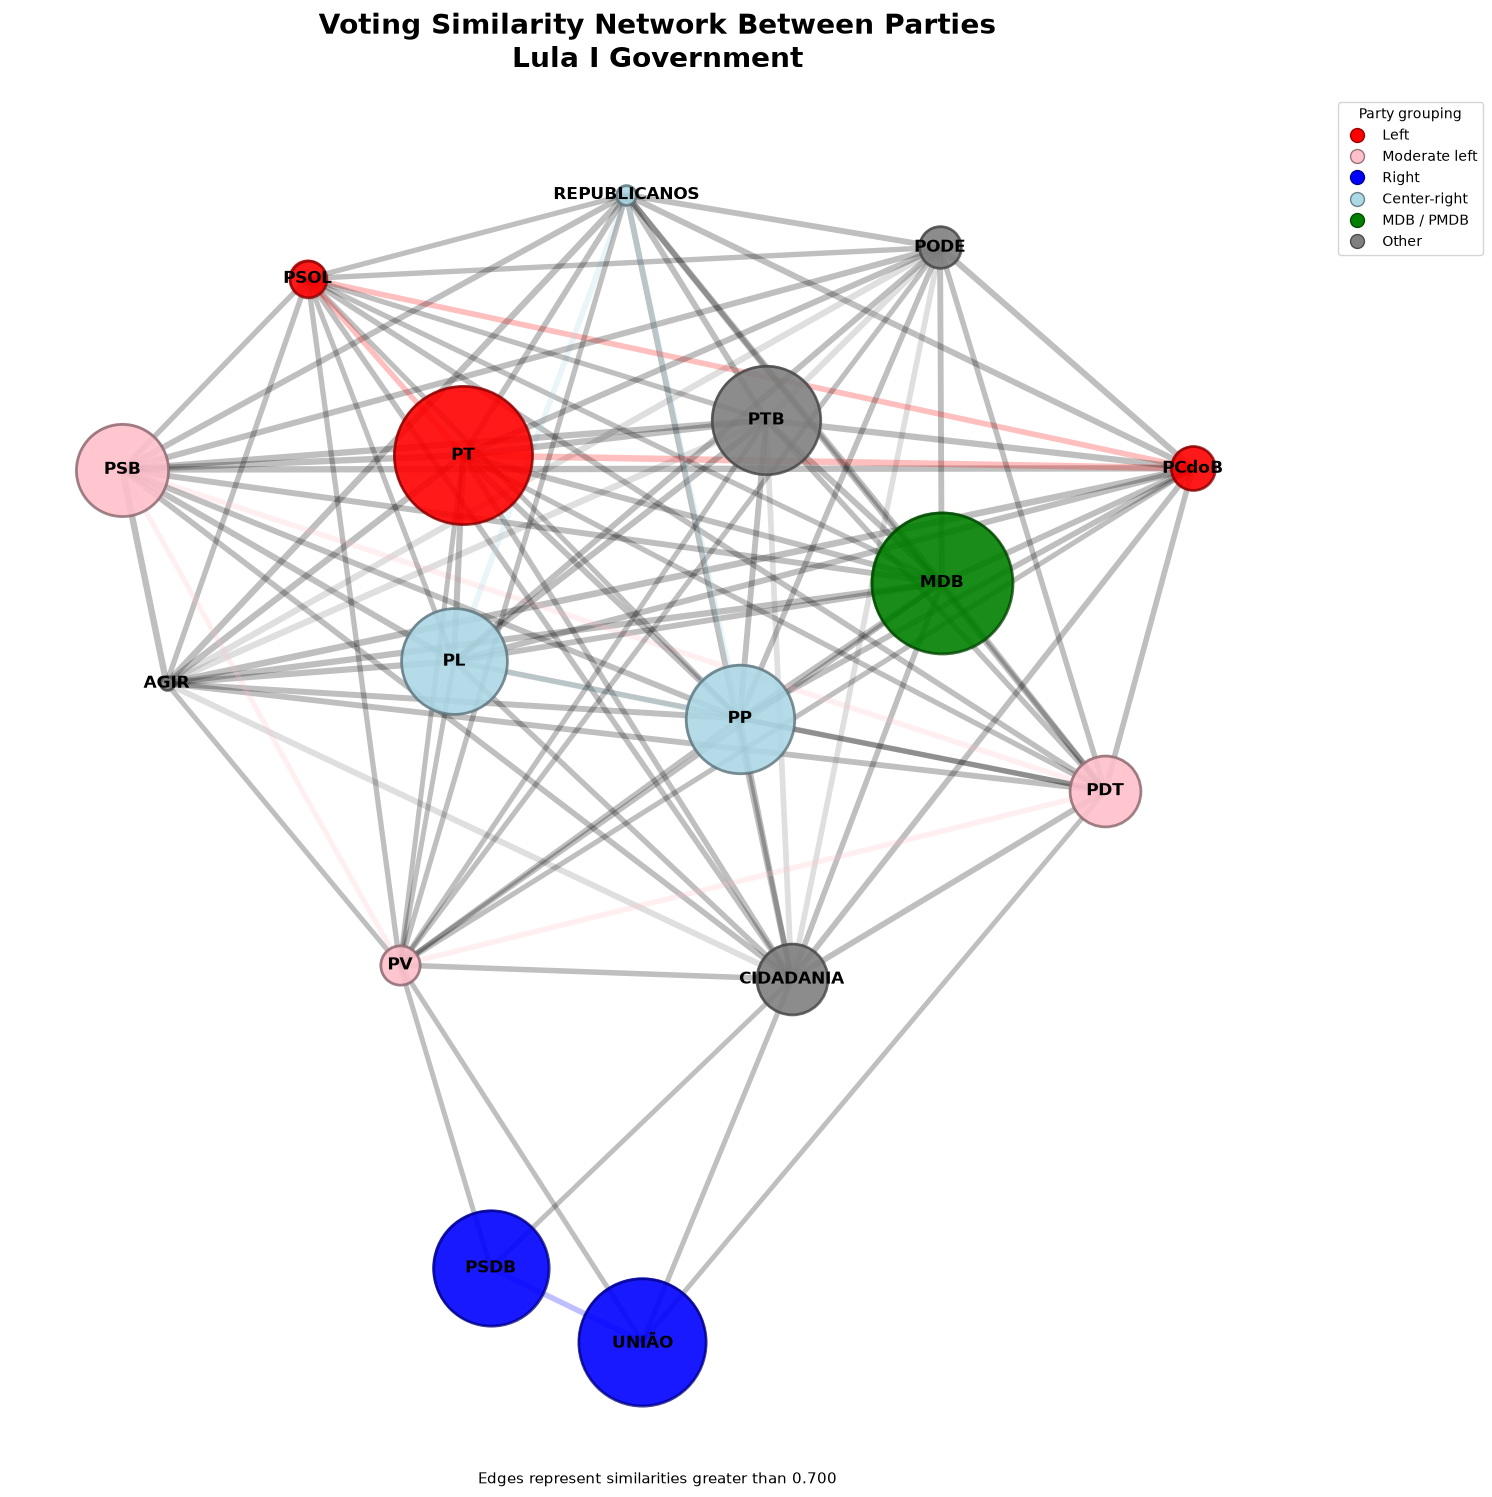

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


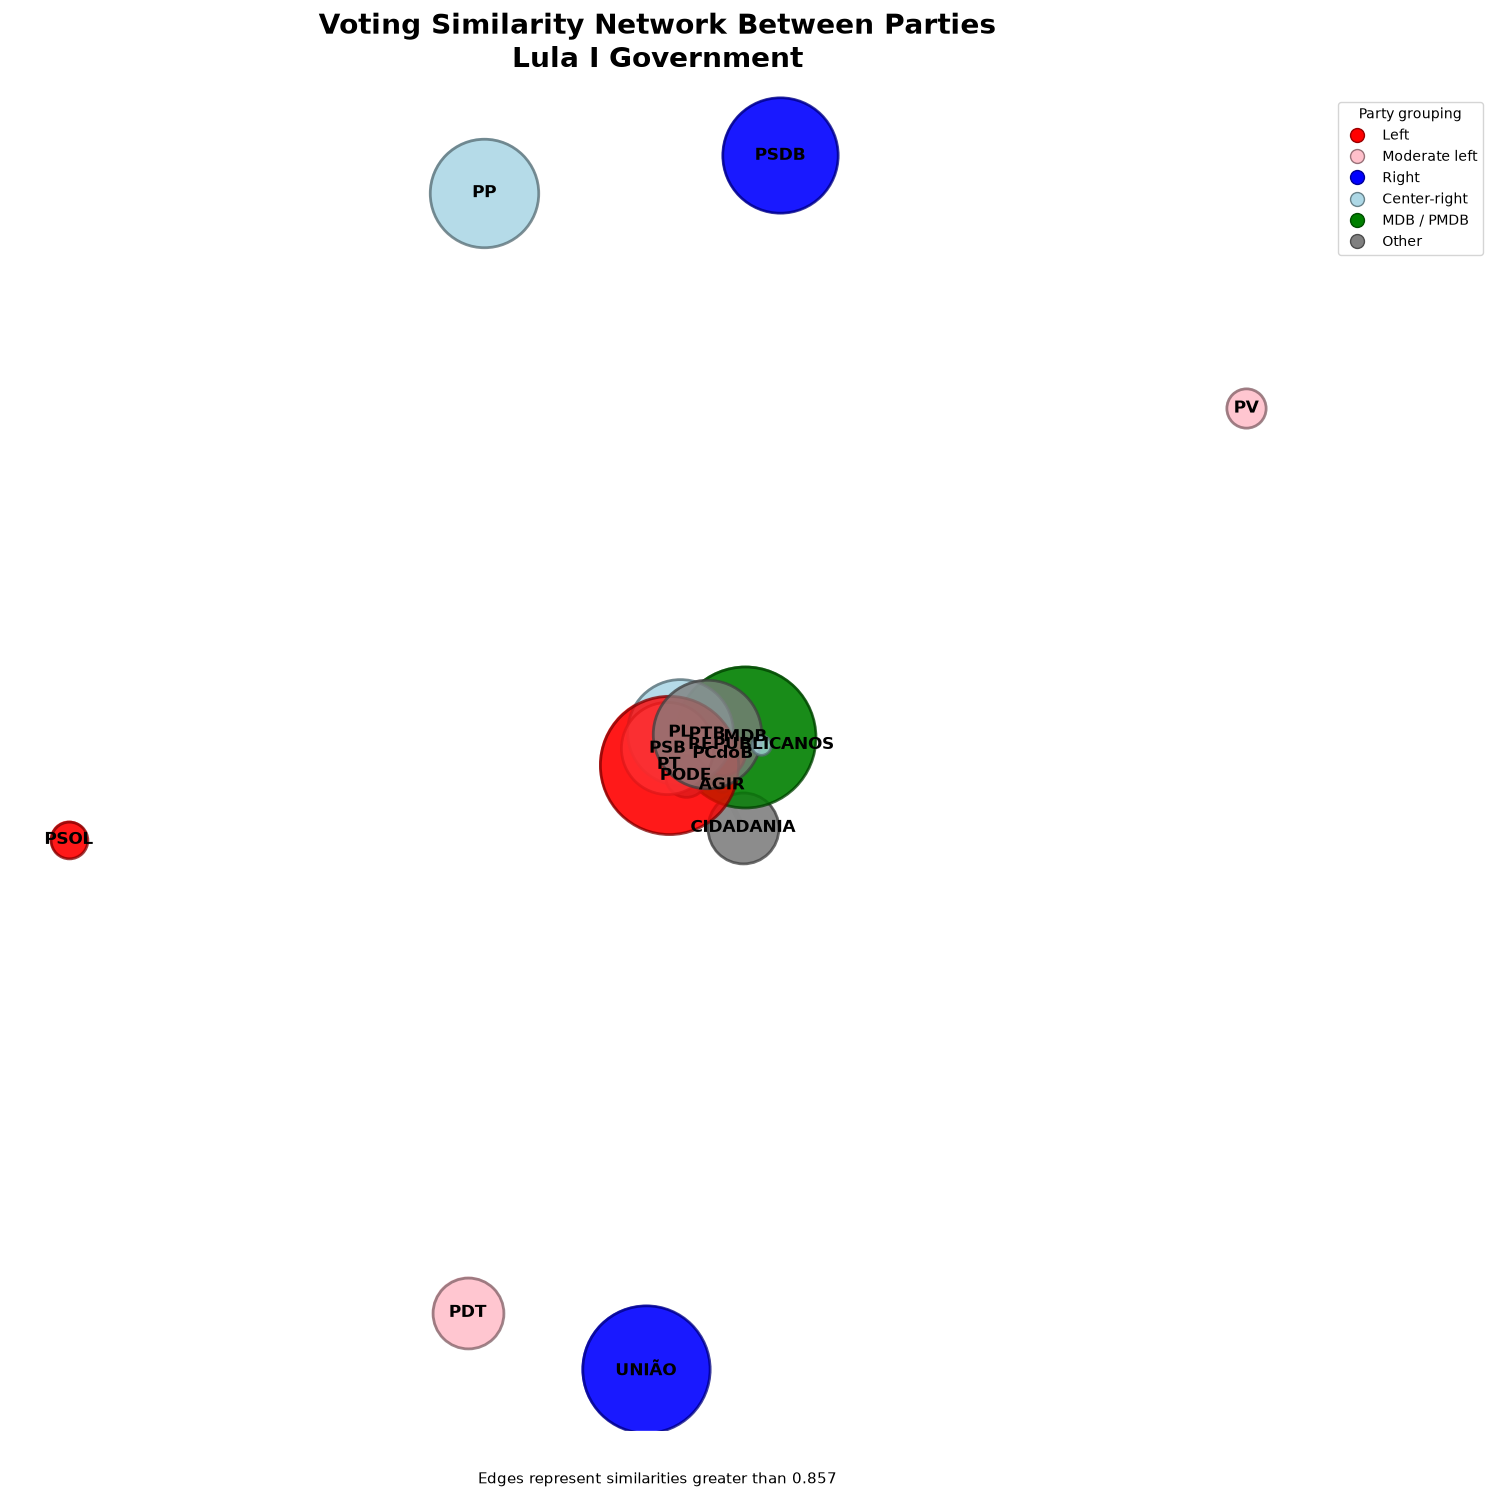

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


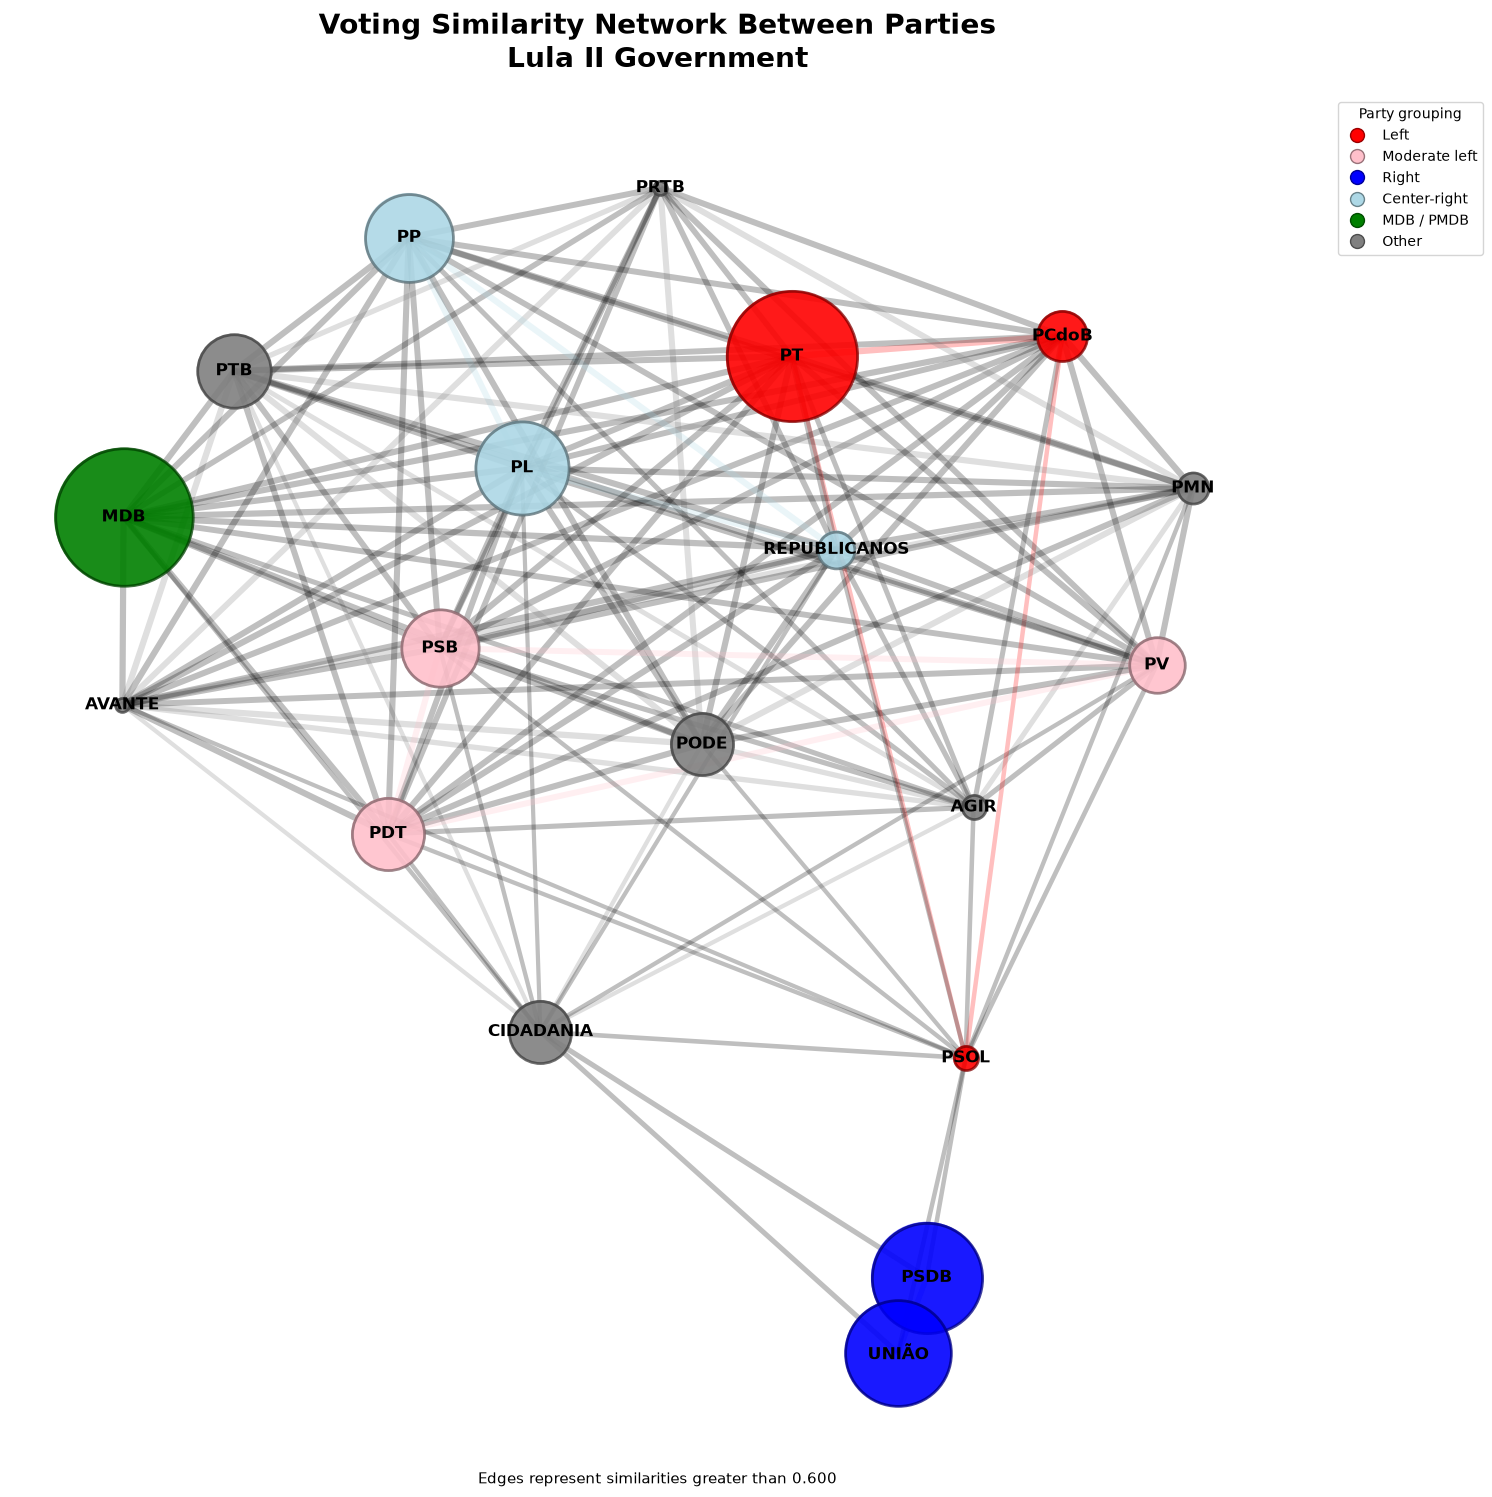

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


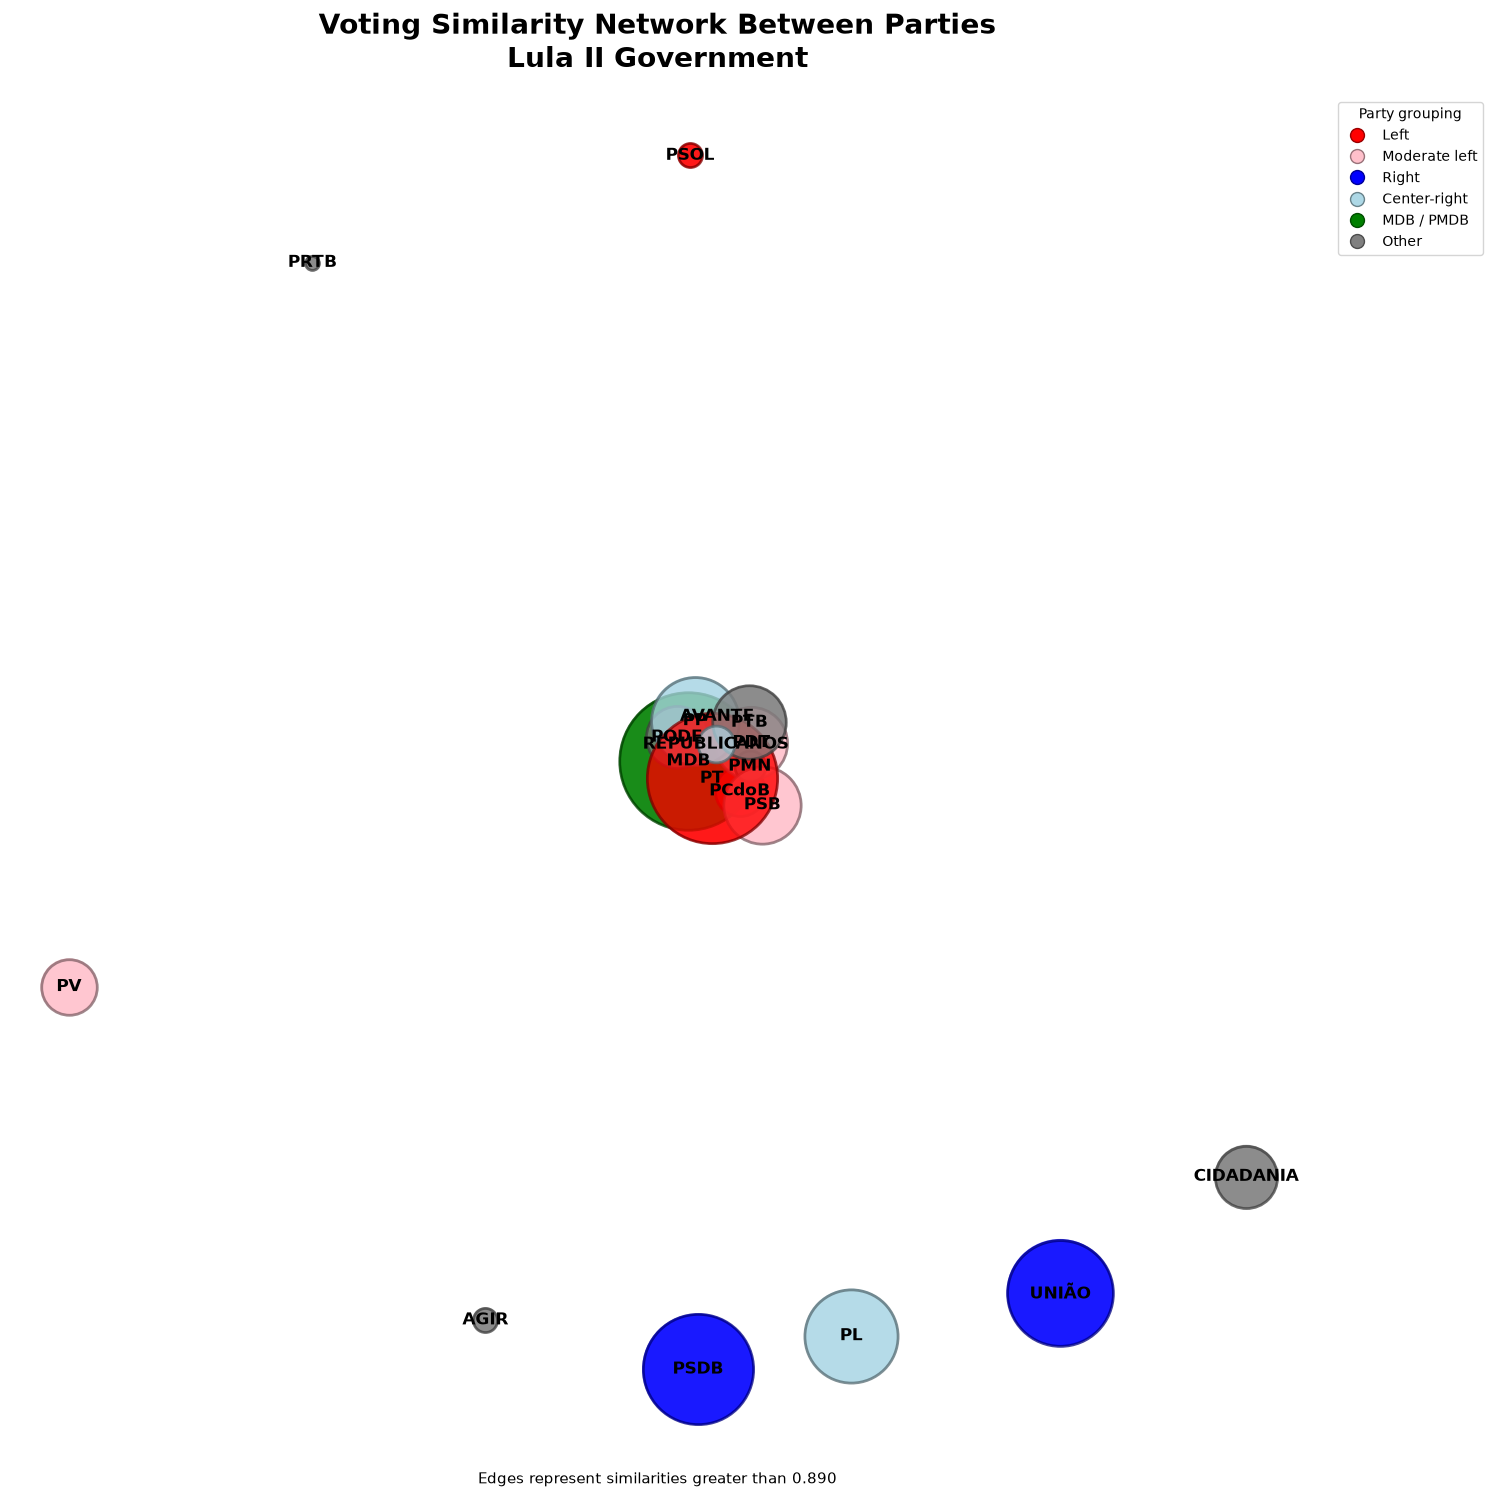

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


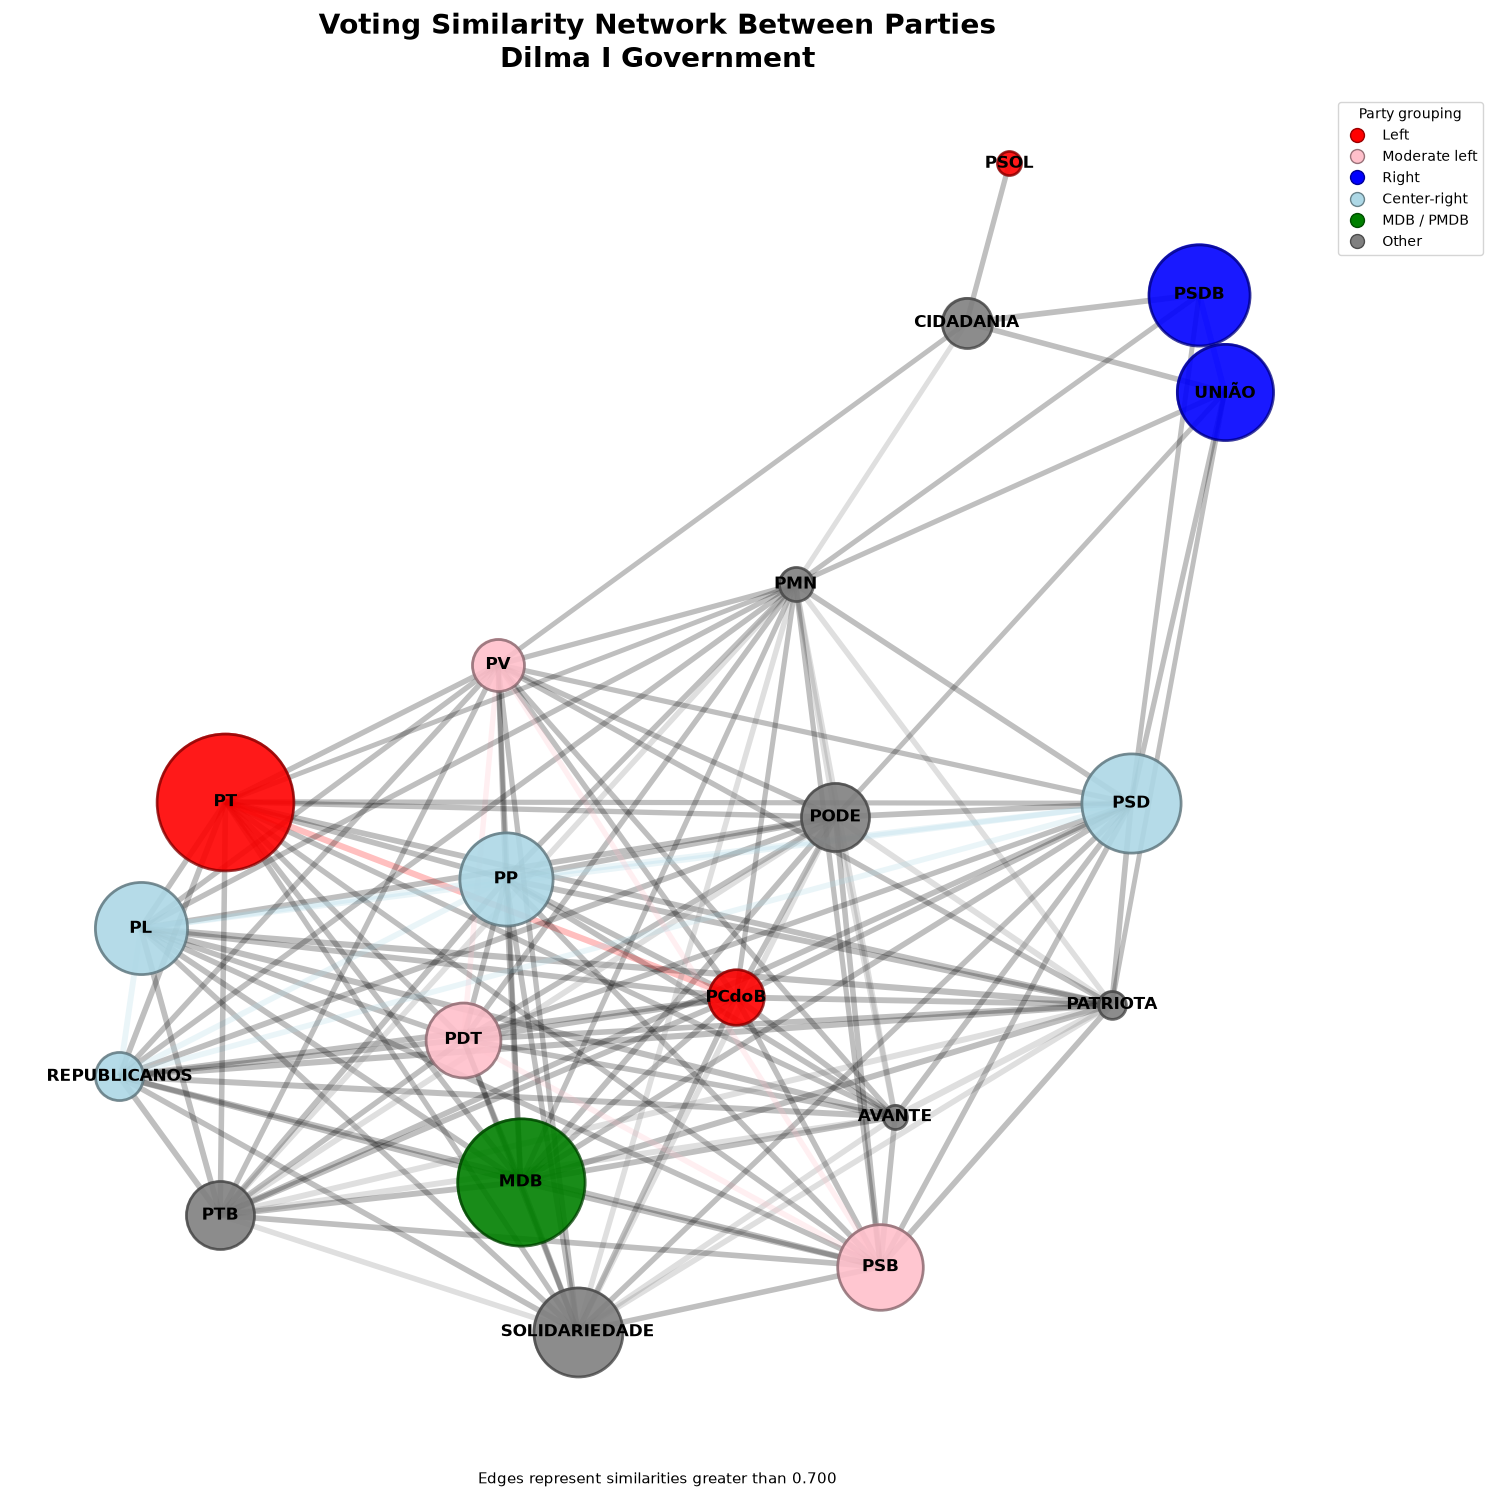

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


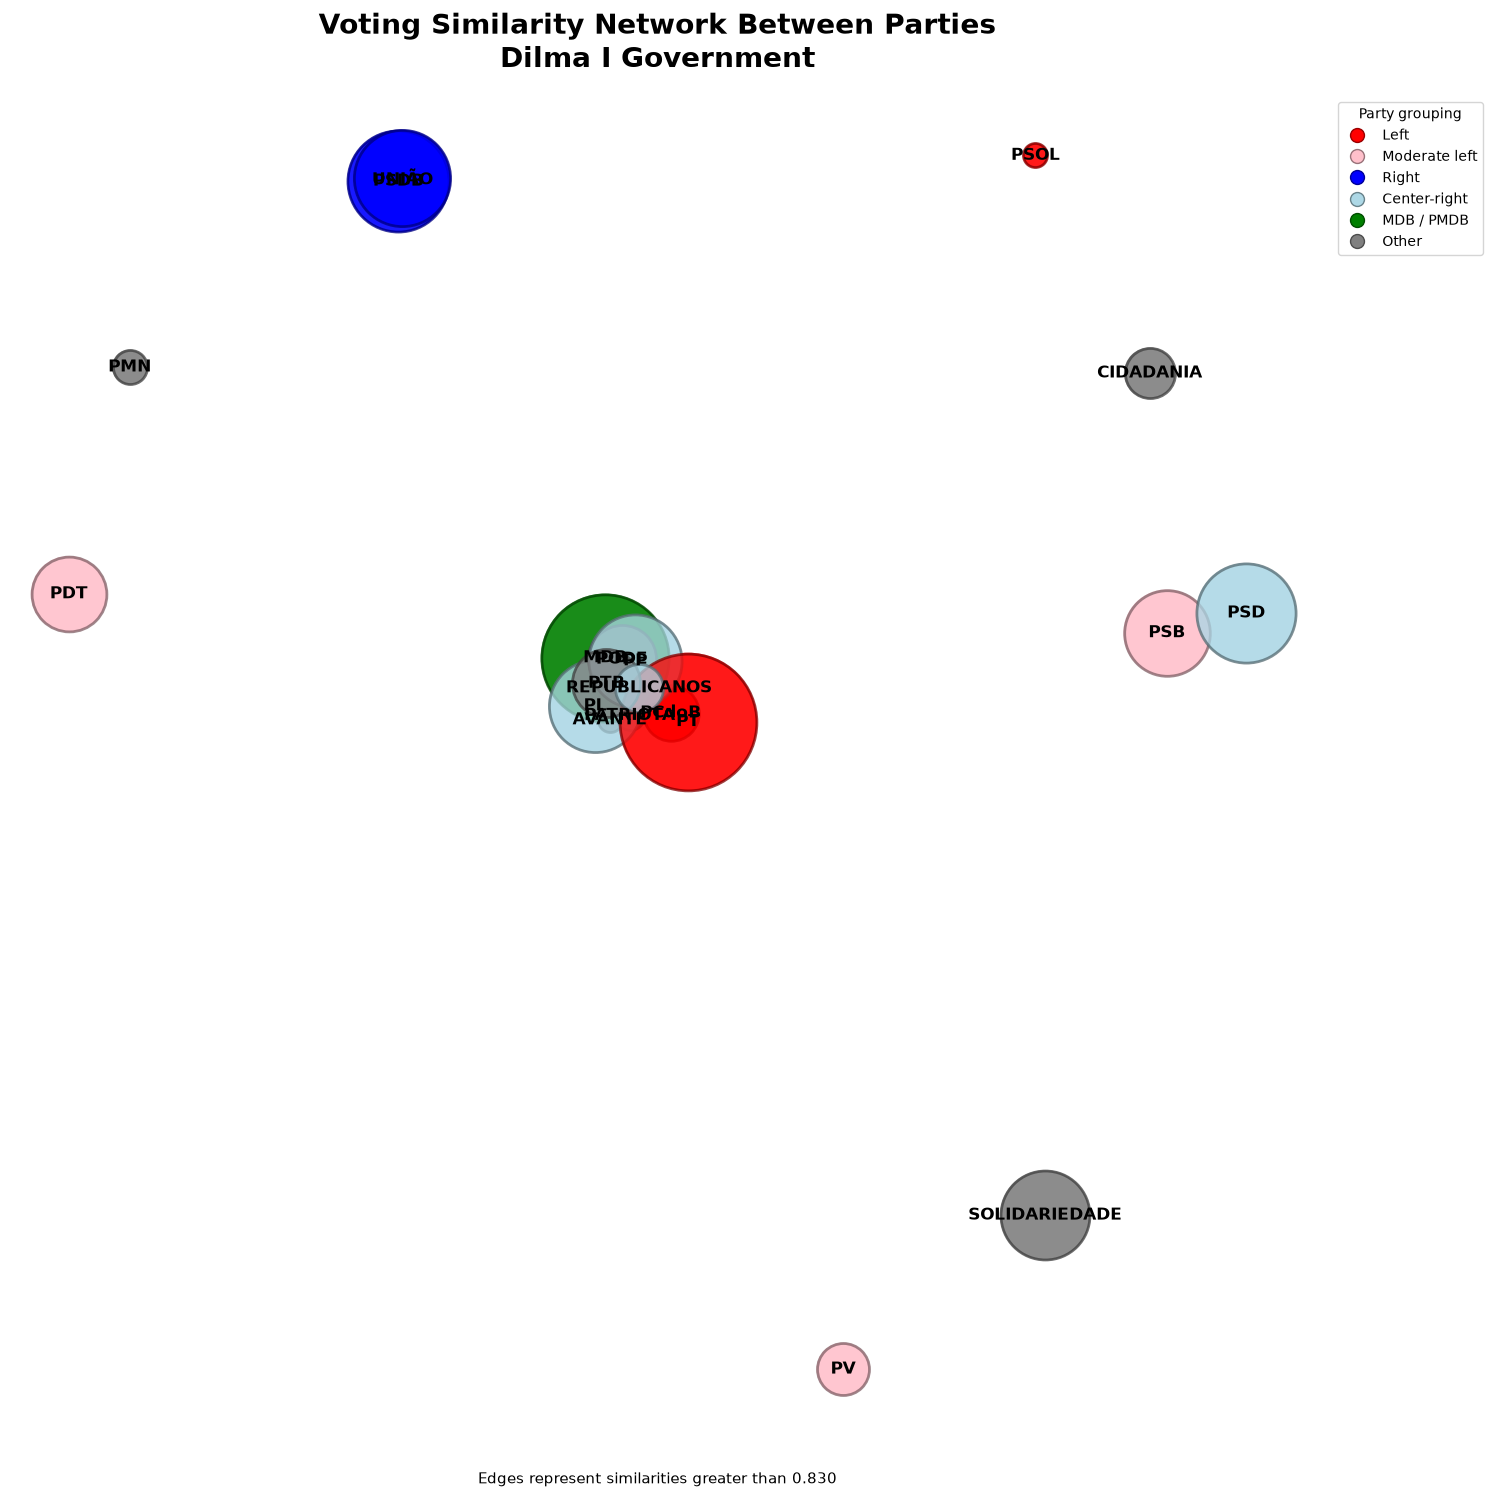

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


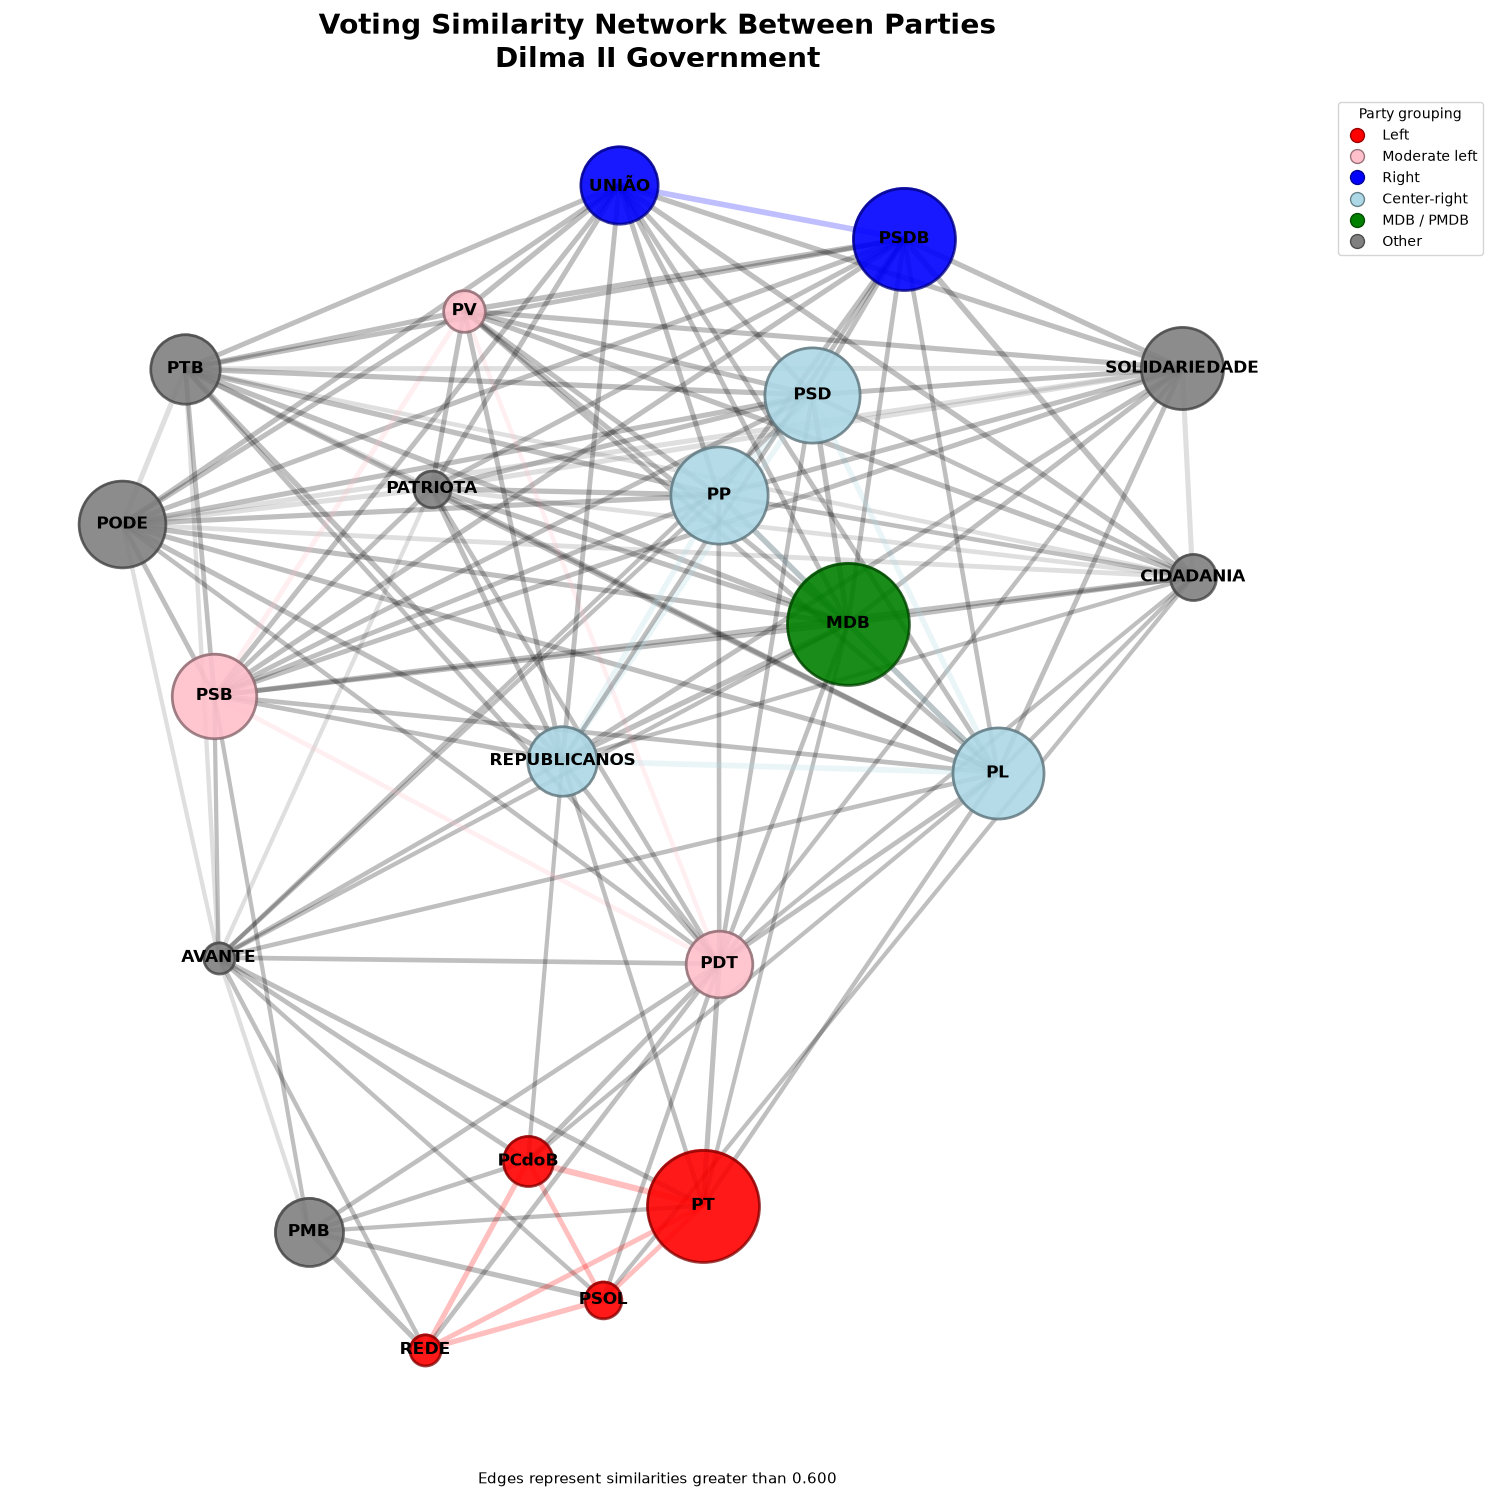

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


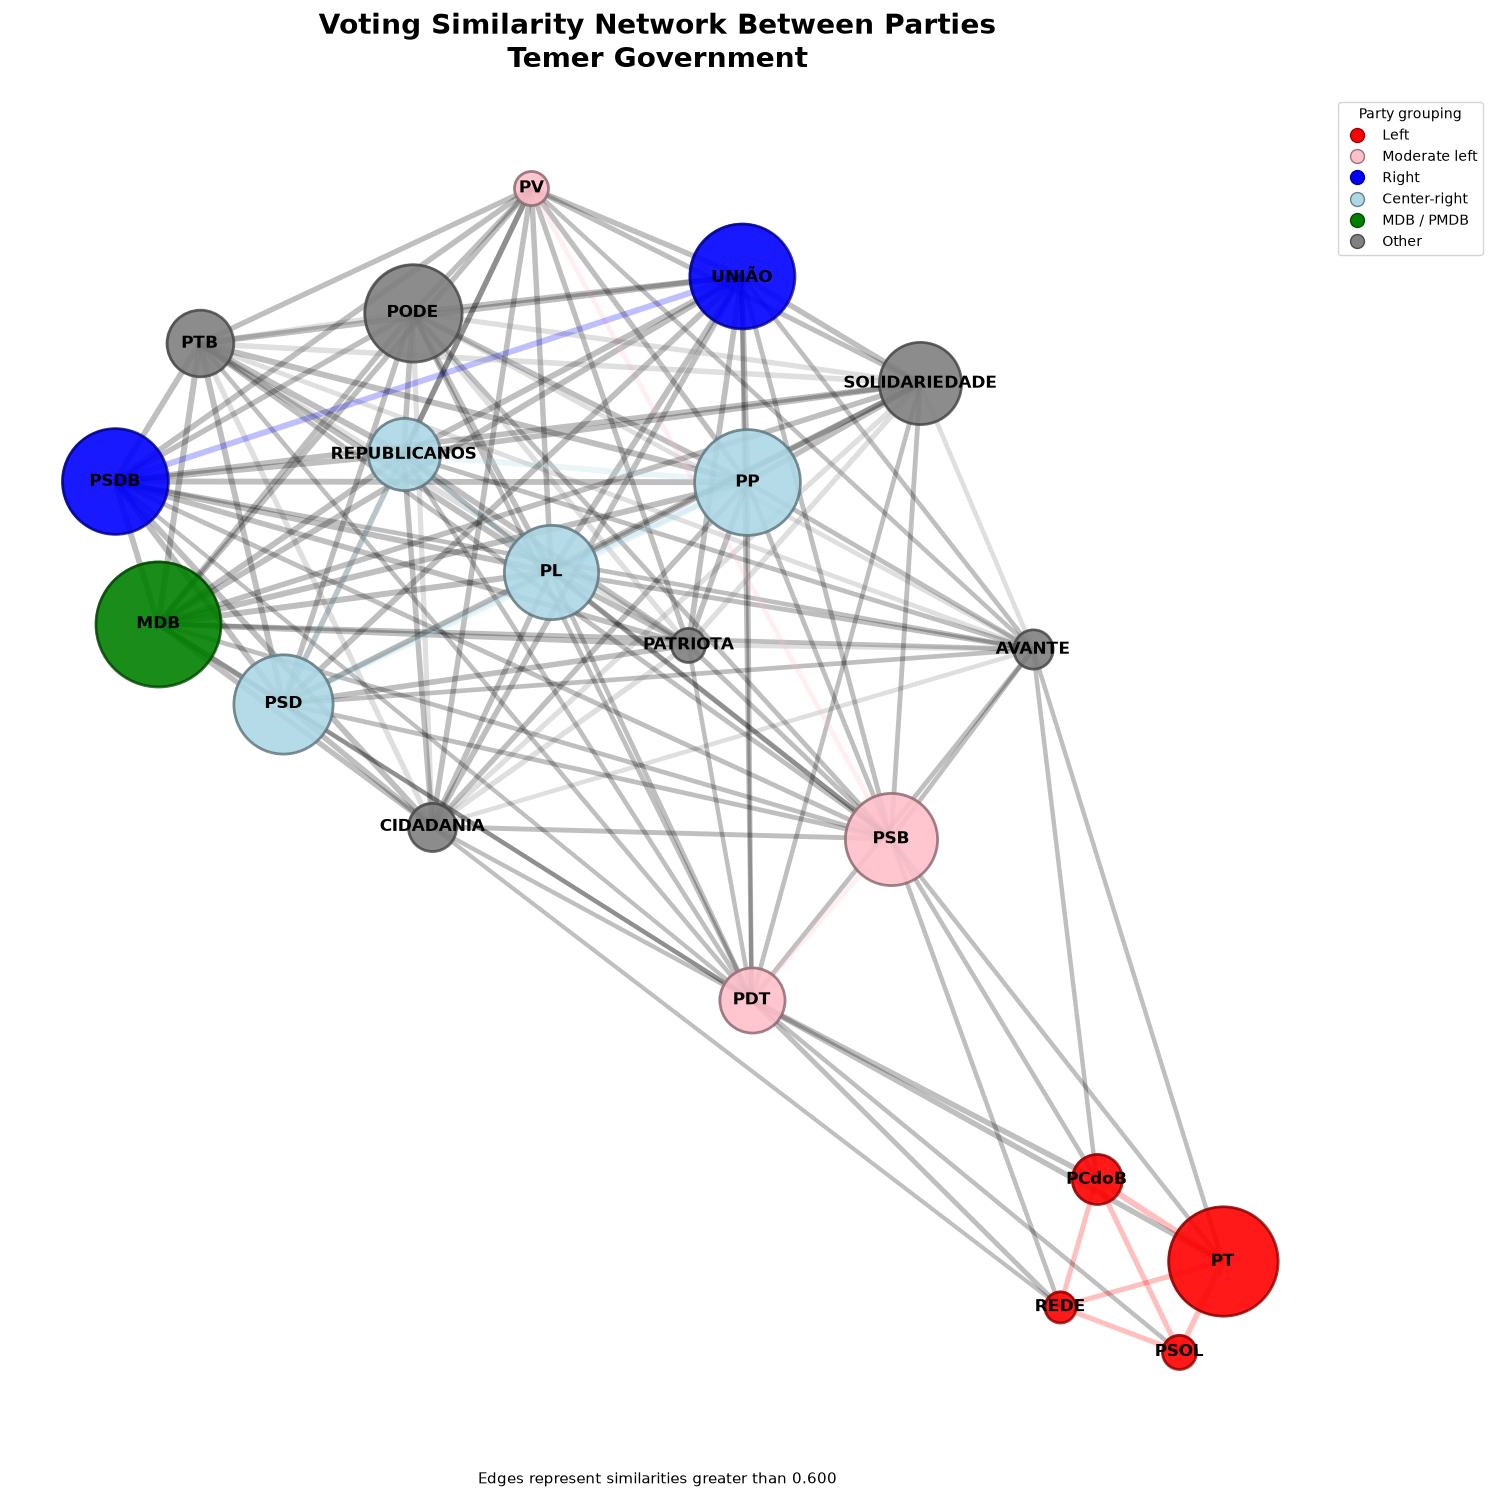

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


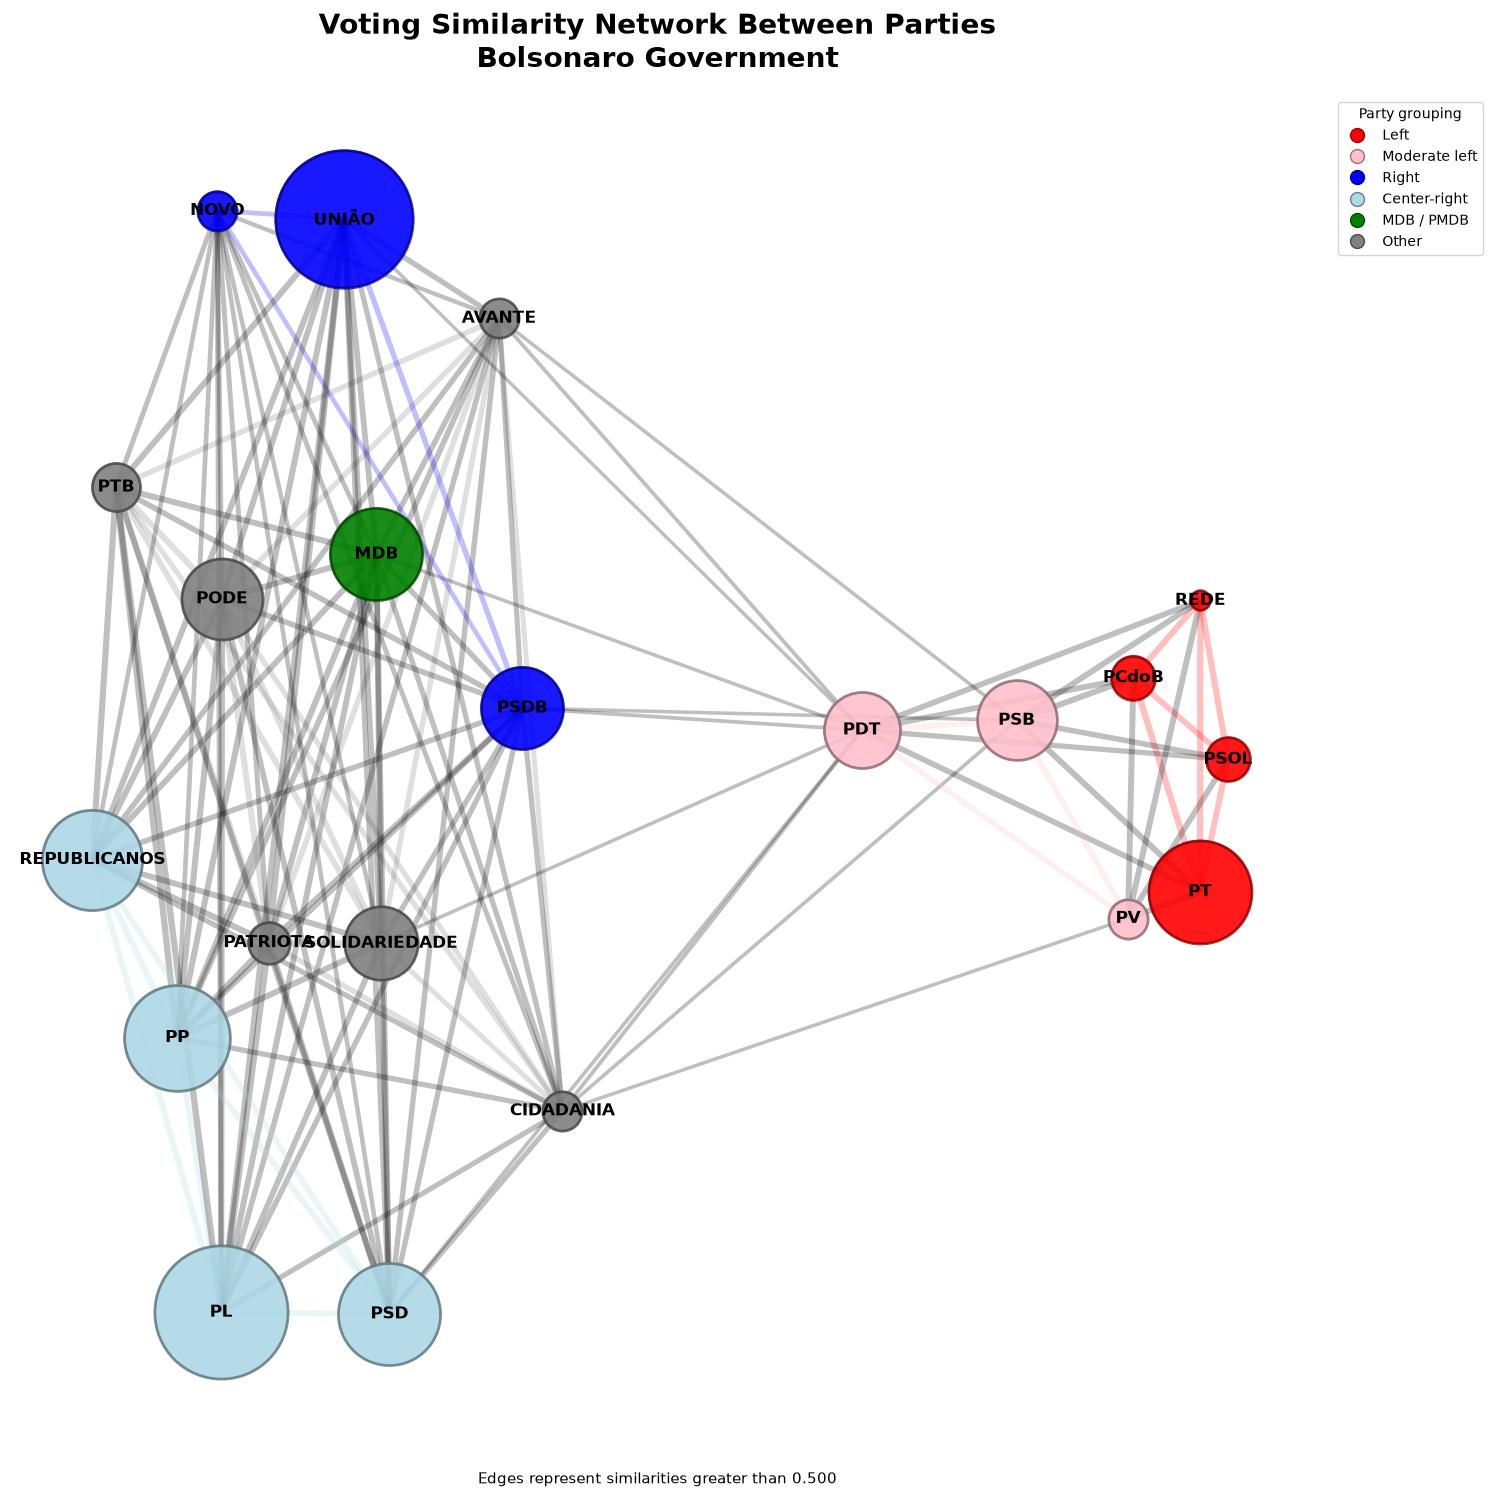

/tmp/ipykernel_33327/2152154930.py:133: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


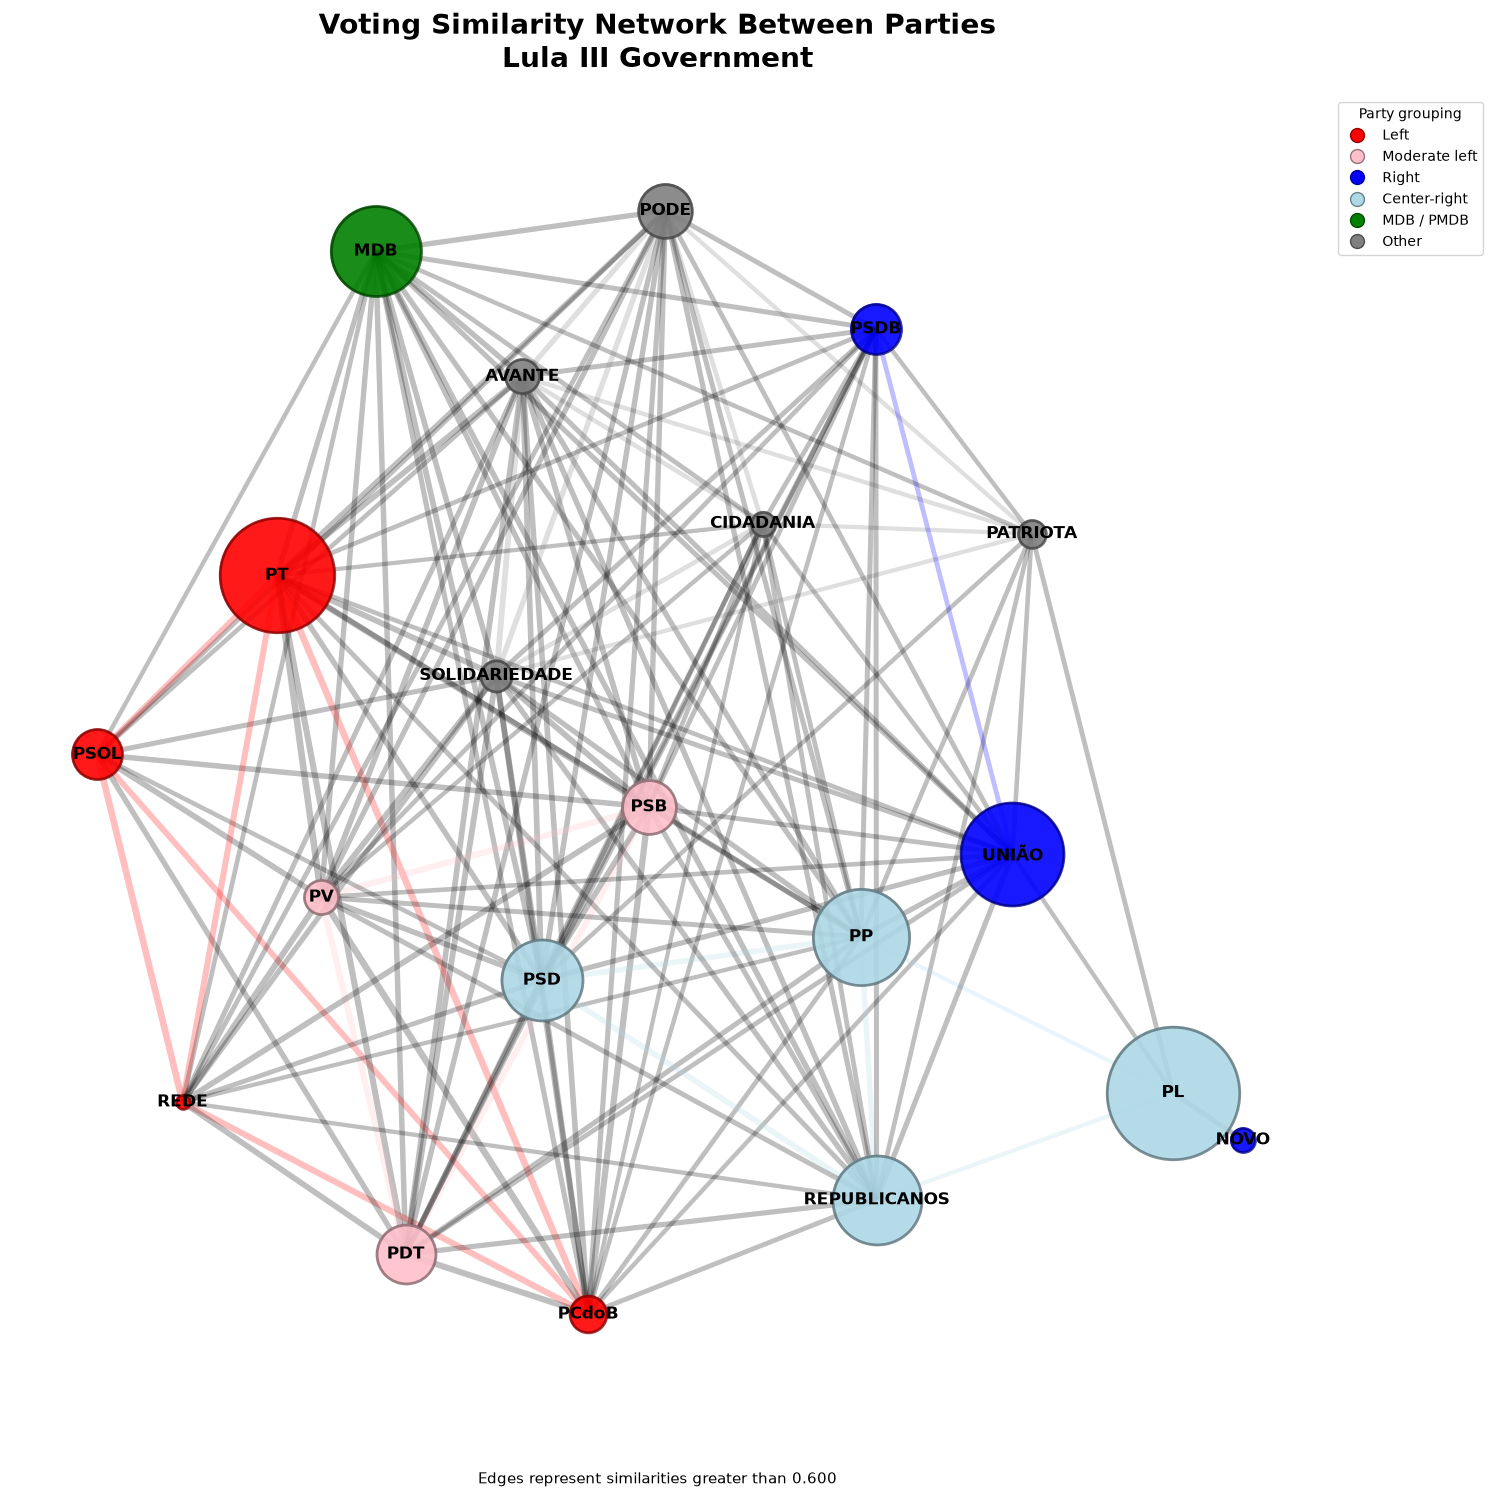

,period,label,threshold,nodes,edges,density,connected_components,figure
0,lula_i,Lula I Government,0.700,16,97,0.808333,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
1,lula_i,Lula I Government,0.857,16,28,0.233333,7,/home/carlos/Carlos/Bahia_Clean_Project/output...
2,lula_ii,Lula II Government,0.600,19,130,0.760234,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
3,lula_ii,Lula II Government,0.890,19,26,0.152047,9,/home/carlos/Carlos/Bahia_Clean_Project/output...
4,dilma_i,Dilma I Government,0.700,20,132,0.694737,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
5,dilma_i,Dilma I Government,0.830,20,26,0.136842,10,/home/carlos/Carlos/Bahia_Clean_Project/output...
6,dilma_ii,Dilma II Government,0.600,21,140,0.666667,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
7,temer,Temer Government,0.600,20,135,0.710526,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
8,bolsonaro,Bolsonaro Government,0.500,21,123,0.585714,1,/home/carlos/Carlos/Bahia_Clean_Project/output...
9,lula_iii,Lula III Government,0.600,20,143,0.752632,1,/home/carlos/Carlos/Bahia_Clean_Project/output...


In [13]:
network_rows = []
graphs = {}

for key, config in NETWORK_CONFIG.items():
    for threshold in config["thresholds"]:
        suffix = str(threshold).replace(".", "_")
        output_name = f"{key}_party_network_t{suffix}.png"

        graph, metrics, output_path = plot_party_network(
            df=period_data[key],
            similarity_matrix=party_similarity[key],
            label=PERIOD_LABELS[key],
            output_name=output_name,
            threshold=threshold,
            scaling_ratio=config["scaling_ratio"],
            gravity=config["gravity"],
            iterations=1000,
            show=True,
        )

        graph_key = f"{key}_t{suffix}"
        graphs[graph_key] = graph

        network_rows.append(
            {
                "period": key,
                "label": PERIOD_LABELS[key],
                "threshold": threshold,
                **metrics,
                "figure": str(output_path),
            }
        )

network_summary = pd.DataFrame(network_rows)
network_summary.to_csv(TABLE_OUTPUT_DIR / "network_summary.csv", index=False)
network_summary

## 13. Optional compatibility aliases

These aliases keep the familiar variable names from the old notebook available for ad-hoc checks without restoring the repeated code.

In [14]:
# Legislature data
df_final_52 = legislatures[52]
df_final_53 = legislatures[53]
df_final_54 = legislatures[54]
df_final_55 = legislatures[55]
df_final_56 = legislatures[56]
df_final_57 = legislatures[57]

df_final_52_limpo = clean_legislatures[52]
df_final_53_limpo = clean_legislatures[53]
df_final_54_limpo = clean_legislatures[54]
df_final_55_limpo = clean_legislatures[55]
df_final_56_limpo = clean_legislatures[56]
df_final_57_limpo = clean_legislatures[57]

df_final_55_1 = period_data["dilma_ii"]
df_final_55_2 = period_data["temer"]

# Deputy similarity matrices
corre_52 = deputy_similarity["lula_i"]
corre_53 = deputy_similarity["lula_ii"]
corre_54 = deputy_similarity["dilma_i"]
corre_55_1 = deputy_similarity["dilma_ii"]
corre_55_2 = deputy_similarity["temer"]
corre_56 = deputy_similarity["bolsonaro"]
corre_57 = deputy_similarity["lula_iii"]

# Party similarity matrices
corre_52_part = party_similarity["lula_i"]
corre_53_part = party_similarity["lula_ii"]
corre_54_part = party_similarity["dilma_i"]
dilma_2_part = party_similarity["dilma_ii"]
temer_part = party_similarity["temer"]
corre_56_part = party_similarity["bolsonaro"]
corre_57_part = party_similarity["lula_iii"]

## 14. Output manifest

This cell lists every file generated by the notebook.

In [15]:
output_files = sorted(
    path.relative_to(OUTPUT_DIR)
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)

print(f"{len(output_files)} output files generated:")
for path in output_files:
    print(f"  - {path}")

79 output files generated:
  - data/.gitkeep
  - data/legislature_52_filtered.csv
  - data/legislature_53_filtered.csv
  - data/legislature_54_filtered.csv
  - data/legislature_55_filtered.csv
  - data/legislature_56_filtered.csv
  - data/legislature_57_filtered.csv
  - data/superplanilha_1.csv
  - figures/.gitkeep
  - figures/average_votes_by_party.png
  - figures/bolsonaro_party_network_t0_5.png
  - figures/deputies_and_substitutes_by_legislature.png
  - figures/deputies_by_party_and_legislature.png
  - figures/deputies_by_state_legislature_52.png
  - figures/deputies_by_state_legislature_53.png
  - figures/deputies_by_state_legislature_54.png
  - figures/deputies_by_state_legislature_55.png
  - figures/deputies_by_state_legislature_56.png
  - figures/deputies_by_state_legislature_57.png
  - figures/dilma_i_party_network_t0_7.png
  - figures/dilma_i_party_network_t0_83.png
  - figures/dilma_ii_party_network_t0_6.png
  - figures/lula_i_party_network_t0_7.png
  - figures/lula_i_party_n